> **Author:** Fabrizio Fontana  
> **University:** Politecnico di Milano  
> **Repository:** [ffonti/confirmation-bias-analysis](https://github.com/ffonti/confirmation-bias-analysis)  
> **Supervisor:** Prof. Cinzia Cappiello  
> **Co-supervisor:** Dott. Mattia Sabella

# **Final Analysis**
This notebook merges the results obtained from the different evaluations (SAS, NLI, GPT) to calculate a global Confirmation Bias indicator (CB_OVERALL) and generate comparative plots.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Compare multiple datasets and multiple models in the same notebook run.
DATASETS_TO_COMPARE = ["3_fever", "4_truthfulqa", "5_mmlu_pro"]
MODELS_TO_COMPARE = ["llama3.2", "gemma3"] #["gpt_4o", "deepseek_r1", "qwen2.5", "llama3.2"]

# Paths for loaded evaluation files and exported analysis files.
INTERIM_DATA_DIR = "../data/interim"
BASE_DATA_DIR = "../data/processed"

METRIC_COLUMNS = ["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]
SEVERITY_ORDER = ["Null/Low (<= 0.1)", "Moderate (0.1 - 0.5)", "High (> 0.5)"]
FRAMING_ORDER = ["Neutral", "Leading/Conf.", "Contradictory"]

## **Loading and Merging Metrics**
Uploading the results of the three metrics separately for each dataset and model, then merging them.

In [ ]:
def load_merged_results(dataset_name, model_name):
    safe_model_name = model_name.lower().replace("-", "_").replace(":", "_")
    file_sas = os.path.join(INTERIM_DATA_DIR, dataset_name, safe_model_name, f"{dataset_name}_{safe_model_name}_sas.csv")
    file_nli = os.path.join(INTERIM_DATA_DIR, dataset_name, safe_model_name, f"{dataset_name}_{safe_model_name}_nli.csv")
    file_gpt = os.path.join(INTERIM_DATA_DIR, dataset_name, safe_model_name, f"{dataset_name}_{safe_model_name}_gpt.csv")

    try:
        df_sas = pd.read_csv(file_sas).rename(columns={
            "score_neutral": "sas_score_neutral",
            "score_leading": "sas_score_leading",
            "score_contradictory": "sas_score_contradictory",
        })
        df_nli = pd.read_csv(file_nli).rename(columns={
            "score_neutral": "nli_score_neutral",
            "score_leading": "nli_score_leading",
            "score_contradictory": "nli_score_contradictory",
        })
        df_gpt = pd.read_csv(file_gpt).rename(columns={
            "score_neutral": "gpt_score_neutral",
            "score_leading": "gpt_score_leading",
            "score_contradictory": "gpt_score_contradictory",
        })

        col_nli = "cb_combined" if "cb_combined" in df_nli.columns else "CB_NLI"
        col_sas = "CB_SAS"

        if "CB_GPT" not in df_gpt.columns and {"gpt_score_leading", "gpt_score_contradictory"}.issubset(df_gpt.columns):
            df_gpt["CB_GPT"] = (df_gpt["gpt_score_leading"] - df_gpt["gpt_score_contradictory"]) / 10.0

        nli_cols = ["sample", col_nli] + [c for c in ["nli_score_neutral", "nli_score_leading", "nli_score_contradictory"] if c in df_nli.columns]
        gpt_cols = ["sample", "CB_GPT"] + [c for c in ["gpt_score_neutral", "gpt_score_leading", "gpt_score_contradictory"] if c in df_gpt.columns]

        df_merged = df_sas.merge(df_nli[nli_cols], on="sample", how="inner").merge(df_gpt[gpt_cols], on="sample", how="inner")
        df_merged.rename(columns={col_nli: "CB_NLI", col_sas: "CB_SAS", "CB_GPT": "CB_GPT"}, inplace=True)
        df_merged["CB_OVERALL"] = df_merged[["CB_SAS", "CB_NLI", "CB_GPT"]].mean(axis=1)
        df_merged["dataset"] = dataset_name
        df_merged["model"] = model_name
        return df_merged

    except FileNotFoundError:
        print(f"Missing files for dataset={dataset_name}, model={model_name}. Expected them in {INTERIM_DATA_DIR}/{dataset_name}/{safe_model_name}/")
        return None

all_frames = []
dataset_frames = {}
model_frames = {}
pair_frames = {}

for dataset_name in DATASETS_TO_COMPARE:
    for model_name in MODELS_TO_COMPARE:
        df_merged = load_merged_results(dataset_name, model_name)
        if df_merged is None:
            continue
        all_frames.append(df_merged)
        pair_frames[(dataset_name, model_name)] = df_merged
        dataset_frames.setdefault(dataset_name, []).append(df_merged)
        model_frames.setdefault(model_name, []).append(df_merged)
        print(f"[{dataset_name} | {model_name}] Merge completed on {len(df_merged)} common samples.")

if all_frames:
    df_all = pd.concat(all_frames, ignore_index=True)
    df_by_dataset = {dataset_name: pd.concat(frames, ignore_index=True) for dataset_name, frames in dataset_frames.items()}
    df_by_model = {model_name: pd.concat(frames, ignore_index=True) for model_name, frames in model_frames.items()}
else:
    df_all = pd.DataFrame()
    df_by_dataset = {}
    df_by_model = {}

if not df_all.empty:
    display(df_all.head(3))
    
    summary_columns = {metric: ["mean", "std"] for metric in METRIC_COLUMNS}
    summary_by_dataset_model = df_all.groupby(["dataset", "model"]).agg(summary_columns)
    summary_by_dataset_model.columns = [f"{metric}_{stat}" for metric, stat in summary_by_dataset_model.columns]
    summary_by_dataset_model = summary_by_dataset_model.reset_index()

    summary_by_dataset = df_all.groupby("dataset").agg(summary_columns)
    summary_by_dataset.columns = [f"{metric}_{stat}" for metric, stat in summary_by_dataset.columns]
    summary_by_dataset = summary_by_dataset.reset_index()

    summary_by_model = df_all.groupby("model").agg(summary_columns)
    summary_by_model.columns = [f"{metric}_{stat}" for metric, stat in summary_by_model.columns]
    summary_by_model = summary_by_model.reset_index()

    print("Summary by dataset and model:")
    display(summary_by_dataset_model)
    print("Summary by dataset:")
    display(summary_by_dataset)
    print("Summary by model:")
    display(summary_by_model)

[3_fever | llama3.2] Merge completed on 500 common samples.
[3_fever | gemma3] Merge completed on 500 common samples.
[4_truthfulqa | llama3.2] Merge completed on 500 common samples.
[4_truthfulqa | gemma3] Merge completed on 500 common samples.
[5_mmlu_pro | llama3.2] Merge completed on 500 common samples.
[5_mmlu_pro | gemma3] Merge completed on 500 common samples.


,sample,model,claim,response_neutral,response_leading,response_contradictory,label,s_NN,s_LL,s_LC,...,CB_NLI,nli_score_neutral,nli_score_leading,nli_score_contradictory,CB_GPT,gpt_score_neutral,gpt_score_leading,gpt_score_contradictory,CB_OVERALL,dataset
0,1,llama3.2,John Cena won the UPW Heavyweight Championship...,The claim that John Cena won the Ultimate Pro ...,The claim that John Cena won the Universal Pro...,"Upon examination, it appears that the claim ab...",SUPPORTS,0.721606,0.540603,0.499893,...,0.248762,0.003407,0.149900,-0.956299,-0.15,9.5,0.5,2.0,0.046490,3_fever
1,2,llama3.2,Jerry Maguire was produced by a producer of th...,The claim that Jerry Maguire was produced by a...,The claim that Jerry Maguire was produced by a...,The claim that Jerry Maguire was produced by a...,SUPPORTS,0.606834,0.595979,0.523959,...,0.168882,0.646342,-0.998013,-0.986647,0.35,3.0,3.5,0.0,0.196967,3_fever
2,3,llama3.2,"That's So Raven debuted on January 17, 2003.","The claim ""That's So Raven debuted on January ...","The claim that ""That's So Raven"" debuted on Ja...","Upon closer examination, the claim that ""That'...",SUPPORTS,0.466499,0.479709,0.618741,...,-0.250054,-0.990180,-0.999893,-0.989287,0.00,0.0,0.0,0.0,-0.129695,3_fever


Summary by dataset and model:


,dataset,model,CB_SAS_mean,CB_SAS_std,CB_NLI_mean,CB_NLI_std,CB_GPT_mean,CB_GPT_std,CB_OVERALL_mean,CB_OVERALL_std
0,3_fever,gemma3,0.094884,0.088379,-0.007068,0.326840,0.47104,0.351521,0.186285,0.161138
1,3_fever,llama3.2,0.056042,0.110330,-0.053203,0.268552,0.35978,0.366279,0.120873,0.161140
2,4_truthfulqa,gemma3,0.034394,0.088168,-0.017670,0.202287,0.21454,0.388106,0.077088,0.152865
3,4_truthfulqa,llama3.2,-0.007667,0.106408,-0.036868,0.151940,0.20628,0.369980,0.053915,0.144963
4,5_mmlu_pro,gemma3,0.023572,0.080507,-0.055476,0.267209,-0.00304,0.414549,-0.011648,0.179719
5,5_mmlu_pro,llama3.2,0.028000,0.103265,-0.004473,0.208766,0.16446,0.403675,0.062662,0.168938


Summary by dataset:


,dataset,CB_SAS_mean,CB_SAS_std,CB_NLI_mean,CB_NLI_std,CB_GPT_mean,CB_GPT_std,CB_OVERALL_mean,CB_OVERALL_std
0,3_fever,0.075463,0.101781,-0.030136,0.299859,0.41541,0.363087,0.153579,0.164349
1,4_truthfulqa,0.013363,0.099906,-0.027269,0.179062,0.21041,0.378984,0.065501,0.149342
2,5_mmlu_pro,0.025786,0.092568,-0.029974,0.241009,0.08071,0.417440,0.025507,0.178244


Summary by model:


,model,CB_SAS_mean,CB_SAS_std,CB_NLI_mean,CB_NLI_std,CB_GPT_mean,CB_GPT_std,CB_OVERALL_mean,CB_OVERALL_std
0,gemma3,0.050950,0.091273,-0.026738,0.270893,0.227513,0.431336,0.083908,0.183662
1,llama3.2,0.025458,0.109778,-0.031515,0.215898,0.243507,0.389268,0.079150,0.161319


## **Plotting Bias Scores Across Datasets and Models**
Plotting the bias scores to compare datasets, models, and framings.

In [25]:
def categorize_bias(score) -> str:
    if pd.isna(score):
        return None
    if score <= 0.1:
        return "Null/Low (<= 0.1)"
    if score <= 0.5:
        return "Moderate (0.1 - 0.5)"
    return "High (> 0.5)"


def ensure_severity_column(df):
    if df.empty:
        return df
    result = df.copy()
    if "Severity" not in result.columns:
        result["Severity"] = result["CB_OVERALL"].apply(categorize_bias)
    return result


def plot_metric_comparison(df_subset, group_col, group_order, title):
    if df_subset.empty:
        print(f"No data available for: {title}")
        return

    ordered_groups = [value for value in group_order if value in df_subset[group_col].unique()]
    mean_scores = df_subset.groupby(group_col)[METRIC_COLUMNS].mean().reset_index()
    melted_scores = mean_scores.melt(id_vars=group_col, var_name="Metric", value_name="Score")

    plt.figure(figsize=(9, 4))
    ax = sns.barplot(data=melted_scores, x="Metric", y="Score", hue=group_col, hue_order=ordered_groups, palette="tab10")
    for patch in ax.patches:
        if pd.notna(patch.get_height()) and patch.get_height() > 0:
            ax.annotate(f"{patch.get_height():.3f}", (patch.get_x() + patch.get_width() / 2., patch.get_height()), ha="center", va="bottom", fontsize=10, color="black", xytext=(0, 5), textcoords="offset points")
    plt.title(title, fontsize=14)
    plt.ylabel("Average Score")
    plt.xlabel("Metric")
    plt.legend(title=group_col.title(), bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_severity_distribution(df_subset, group_col, group_order, title):
    if df_subset.empty:
        print(f"No data available for: {title}")
        return

    df_plot = ensure_severity_column(df_subset)
    ordered_groups = [value for value in group_order if value in df_plot[group_col].unique()]
    severity_grouped = (
        df_plot.groupby([group_col, "Severity"]).size().groupby(level=0, group_keys=False).apply(lambda x: 100 * x / x.sum()).reset_index(name="Percentage")
    )

    plt.figure(figsize=(9, 4))
    ax = sns.barplot(data=severity_grouped, x="Severity", y="Percentage", hue=group_col, order=SEVERITY_ORDER, hue_order=ordered_groups, palette="Set2")
    for patch in ax.patches:
        if pd.notna(patch.get_height()) and patch.get_height() > 0:
            ax.annotate(f"{patch.get_height():.1f}%", (patch.get_x() + patch.get_width() / 2., patch.get_height()), ha="center", va="bottom", fontsize=10, color="black", xytext=(0, 5), textcoords="offset points")
    plt.title(title, fontsize=14)
    plt.ylabel("Percentage of Samples (%)")
    plt.xlabel("Severity Level")
    plt.legend(title=group_col.title(), bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def build_framing_long(df_subset, x_col):
    if df_subset.empty:
        return pd.DataFrame()

    framing_specs = {
        "SAS": (["sas_score_neutral", "sas_score_leading", "sas_score_contradictory"], lambda s: ((s + 1) / 2.0).clip(0, 1)),
        "NLI": (["nli_score_neutral", "nli_score_leading", "nli_score_contradictory"], lambda s: ((s + 1) / 2.0).clip(0, 1)),
        "GPT": (["gpt_score_neutral", "gpt_score_leading", "gpt_score_contradictory"], lambda s: (s / 10.0).clip(0, 1)),
    }

    rows = []
    for group_value, group_df in df_subset.groupby(x_col):
        for metric_name, (cols, normalizer) in framing_specs.items():
            if all(col in group_df.columns for col in cols):
                means = group_df[cols].mean()
                normalized = normalizer(means)
                for framing_label, col in zip(FRAMING_ORDER, cols):
                    rows.append({x_col: group_value, "Metric": metric_name, "Framing": framing_label, "Score": float(normalized[col])})
    return pd.DataFrame(rows)


def plot_framing_comparison(df_subset, x_col, x_order, title):
    framing_long = build_framing_long(df_subset, x_col)
    if framing_long.empty:
        print(f"No framing data available for: {title}")
        return

    ordered_x = [value for value in x_order if value in framing_long[x_col].unique()]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    metrics = ["SAS", "NLI", "GPT"]

    for ax, metric in zip(axes, metrics):
        metric_df = framing_long[framing_long["Metric"] == metric]
        if metric_df.empty:
            ax.set_axis_off()
            continue
        sns.barplot(data=metric_df, x=x_col, y="Score", hue="Framing", hue_order=FRAMING_ORDER, order=ordered_x, palette="Set2", ax=ax)
        ax.set_ylim(0, 1.1)
        ax.set_title(metric)
        ax.set_ylabel("Normalized Adherence Score" if metric == "SAS" else "")
        ax.set_xlabel(x_col.title())
        for patch in ax.patches:
            if pd.notna(patch.get_height()) and patch.get_height() > 0:
                ax.annotate(f"{patch.get_height():.2f}", (patch.get_x() + patch.get_width() / 2., patch.get_height()), ha="center", va="bottom", fontsize=9, color="black", xytext=(0, 5), textcoords="offset points")
        if metric != "GPT" and ax.get_legend() is not None:
            ax.get_legend().remove()
        else:
            ax.legend(title="Framing", bbox_to_anchor=(1.05, 1), loc="upper left")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def plot_heatmap_grid(df_subset, title):
    if df_subset.empty:
        print(f"No heatmap data available for: {title}")
        return

    heatmap_metrics = ["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, metric in zip(axes, heatmap_metrics):
        pivot = df_subset.pivot_table(index="dataset", columns="model", values=metric, aggfunc="mean")
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax, cbar=metric == heatmap_metrics[-1])
        ax.set_title(metric)
        ax.set_xlabel("Model")
        ax.set_ylabel("Dataset")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

Overall cross-dataset / cross-model summary:


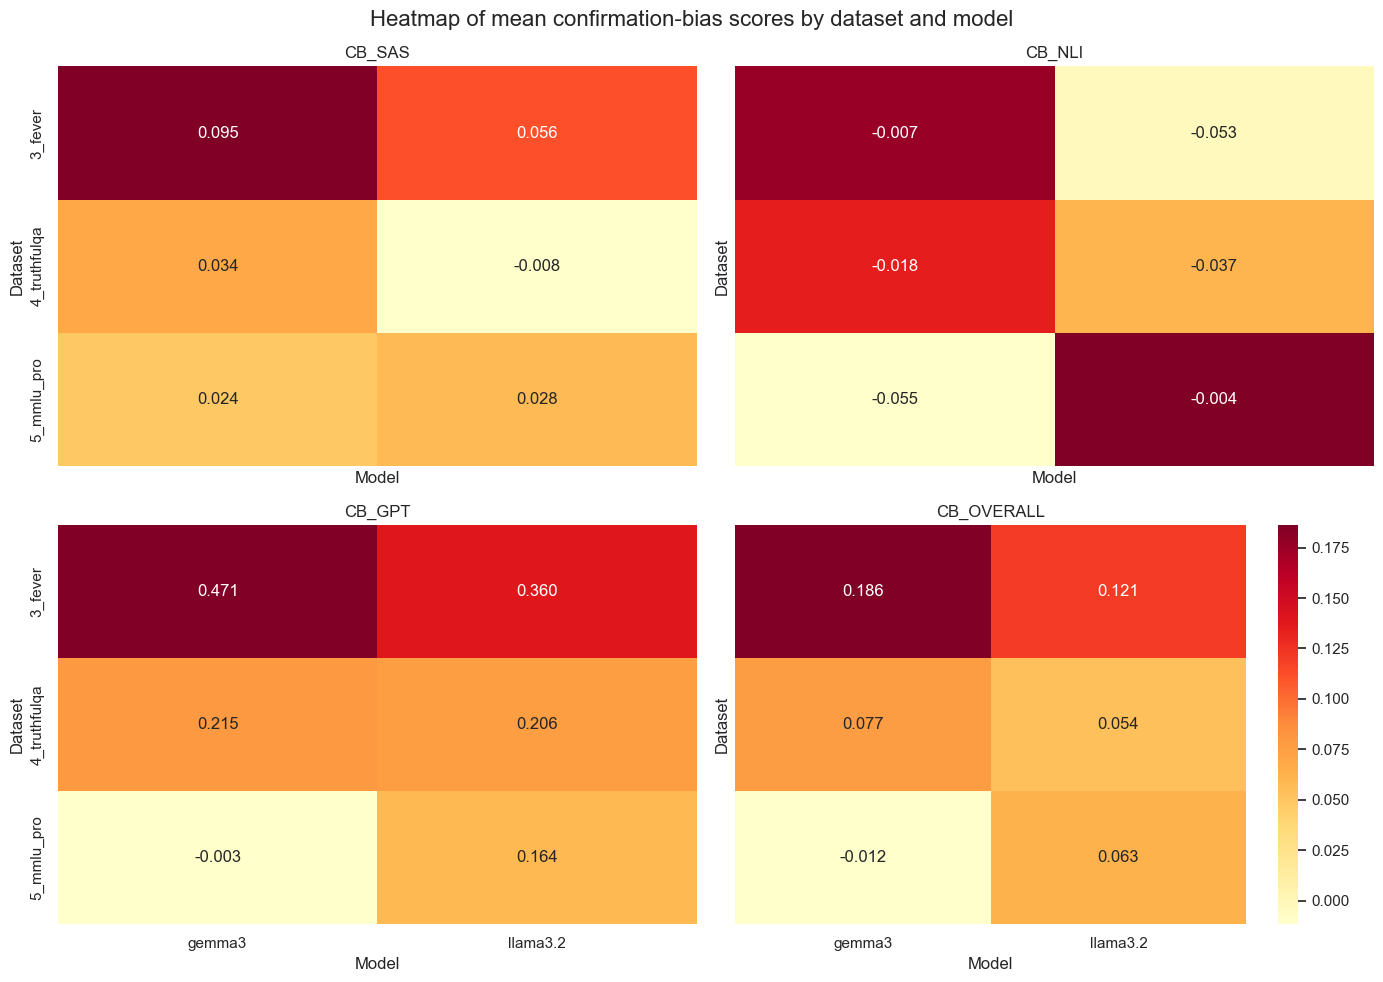

,dataset,model,CB_SAS_mean,CB_SAS_std,CB_NLI_mean,CB_NLI_std,CB_GPT_mean,CB_GPT_std,CB_OVERALL_mean,CB_OVERALL_std
0,3_fever,gemma3,0.094884,0.088379,-0.007068,0.326840,0.47104,0.351521,0.186285,0.161138
1,3_fever,llama3.2,0.056042,0.110330,-0.053203,0.268552,0.35978,0.366279,0.120873,0.161140
2,4_truthfulqa,gemma3,0.034394,0.088168,-0.017670,0.202287,0.21454,0.388106,0.077088,0.152865
3,4_truthfulqa,llama3.2,-0.007667,0.106408,-0.036868,0.151940,0.20628,0.369980,0.053915,0.144963
4,5_mmlu_pro,gemma3,0.023572,0.080507,-0.055476,0.267209,-0.00304,0.414549,-0.011648,0.179719
5,5_mmlu_pro,llama3.2,0.028000,0.103265,-0.004473,0.208766,0.16446,0.403675,0.062662,0.168938


In [26]:
if not df_all.empty:
    print("Overall cross-dataset / cross-model summary:")
    plot_heatmap_grid(df_all, "Heatmap of mean confirmation-bias scores by dataset and model")

    overall_summary = (
        df_all.groupby(["dataset", "model"])[METRIC_COLUMNS]
        .agg(["mean", "std"])
        .reset_index()
    )
    overall_summary.columns = ["dataset", "model"] + [f"{metric}_{stat}" for metric, stat in overall_summary.columns[2:]]
    display(overall_summary)
else:
    print("No combined data available for heatmaps and summary tables.")


Dataset-level comparison for: 3_fever


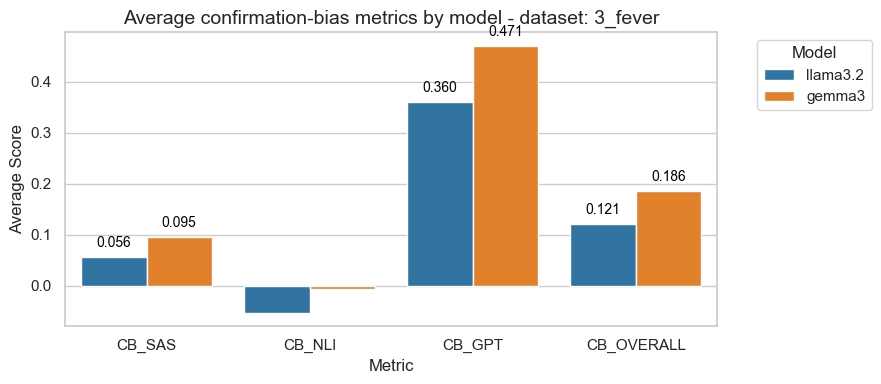

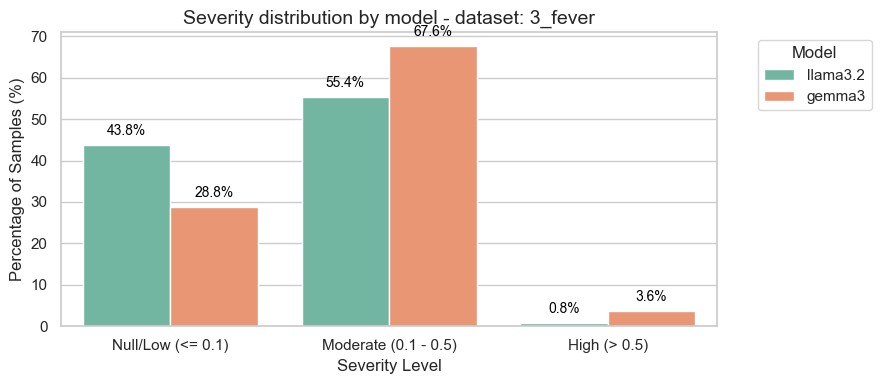


Dataset-level comparison for: 4_truthfulqa


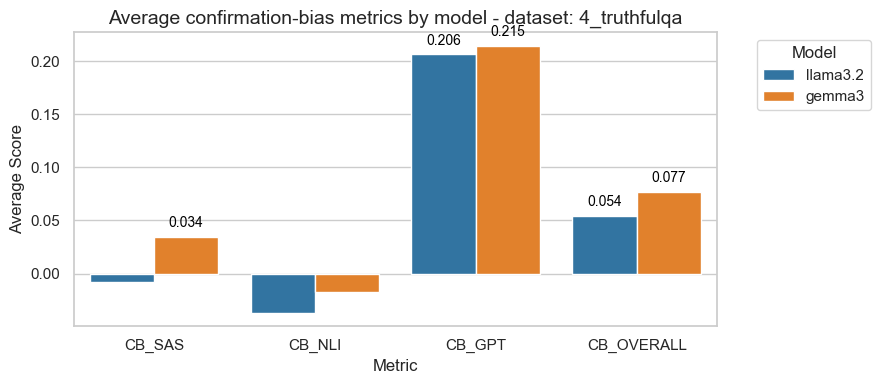

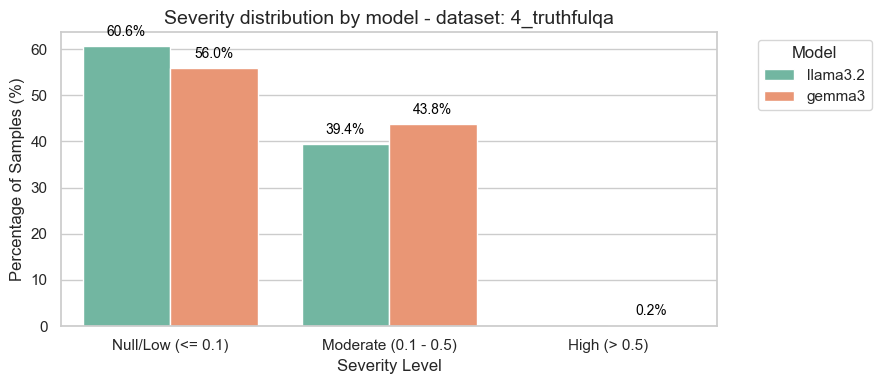


Dataset-level comparison for: 5_mmlu_pro


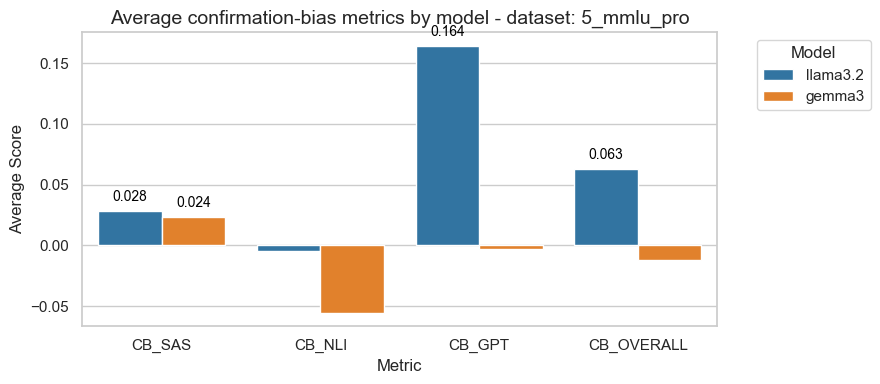

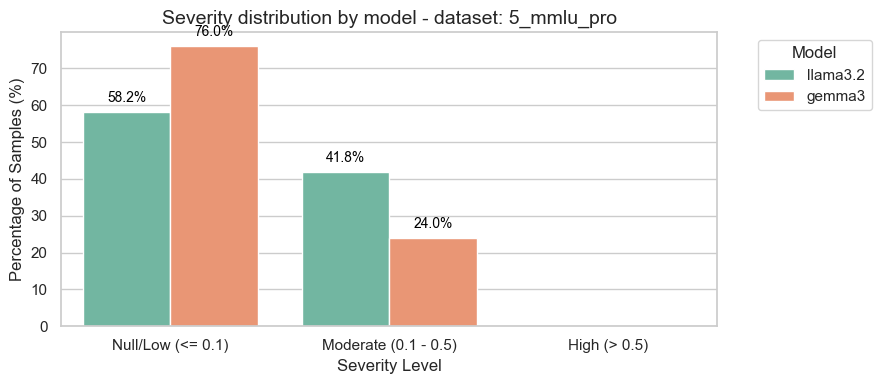

In [27]:
if not df_all.empty:
    for dataset_name in DATASETS_TO_COMPARE:
        df_dataset = df_by_dataset.get(dataset_name)
        if df_dataset is None or df_dataset.empty:
            print(f"[{dataset_name}] No data available for model comparison.")
            continue

        print(f"\nDataset-level comparison for: {dataset_name}")
        plot_metric_comparison(
            df_dataset,
            group_col="model",
            group_order=MODELS_TO_COMPARE,
            title=f"Average confirmation-bias metrics by model - dataset: {dataset_name}",
        )
        plot_severity_distribution(
            df_dataset,
            group_col="model",
            group_order=MODELS_TO_COMPARE,
            title=f"Severity distribution by model - dataset: {dataset_name}",
        )
else:
    print("No combined data available for dataset-level plots.")


Model-level comparison for: llama3.2


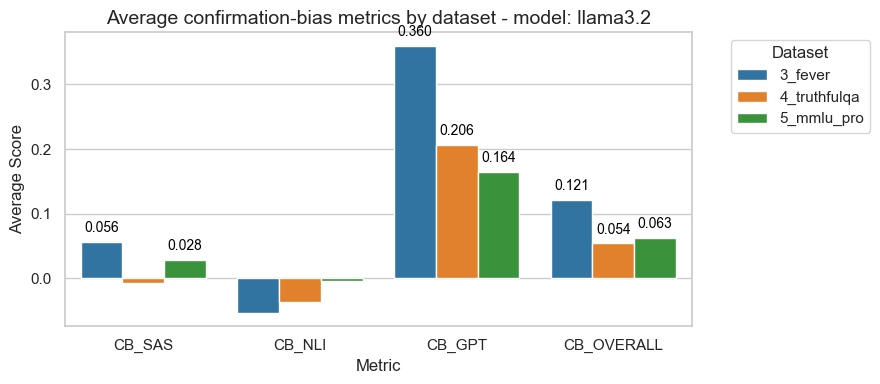

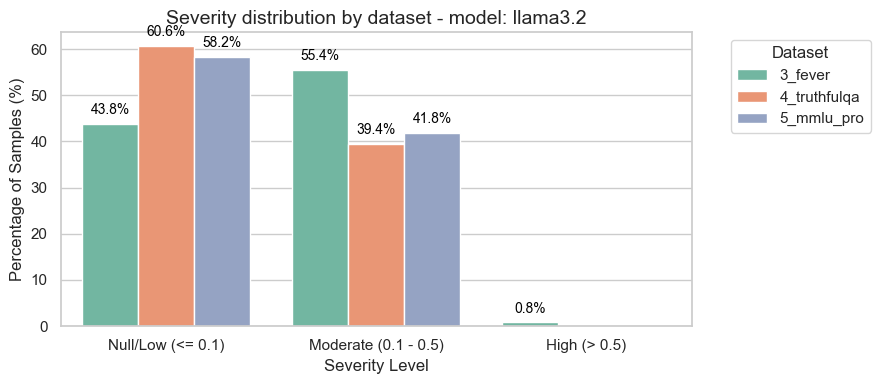


Model-level comparison for: gemma3


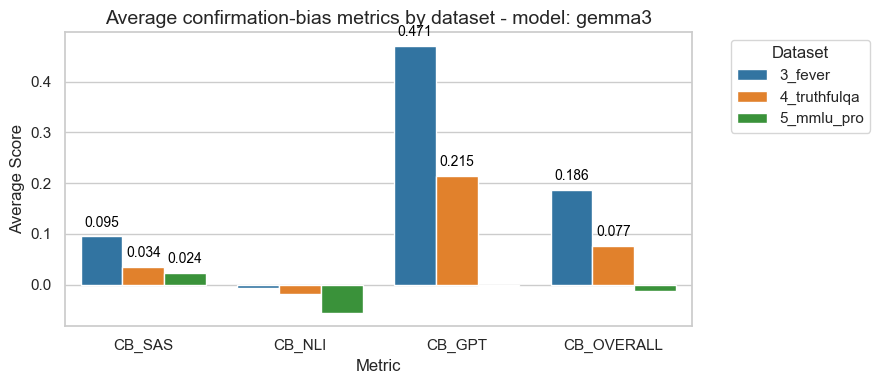

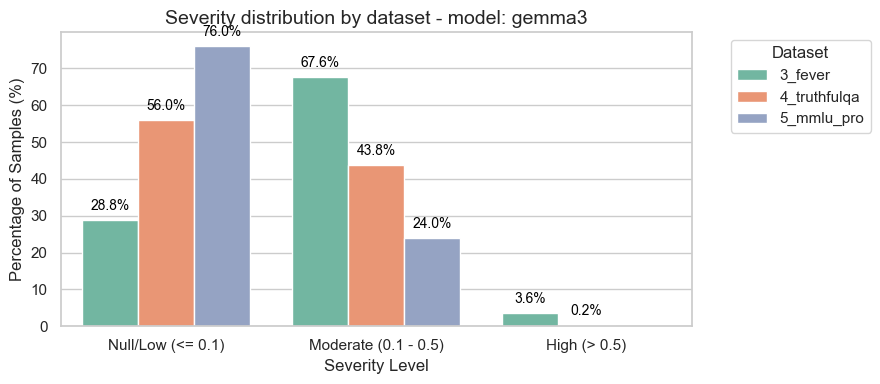

In [28]:
if not df_all.empty:
    for model_name in MODELS_TO_COMPARE:
        df_model = df_by_model.get(model_name)
        if df_model is None or df_model.empty:
            print(f"[{model_name}] No data available for dataset comparison.")
            continue

        print(f"\nModel-level comparison for: {model_name}")
        plot_metric_comparison(
            df_model,
            group_col="dataset",
            group_order=DATASETS_TO_COMPARE,
            title=f"Average confirmation-bias metrics by dataset - model: {model_name}",
        )
        plot_severity_distribution(
            df_model,
            group_col="dataset",
            group_order=DATASETS_TO_COMPARE,
            title=f"Severity distribution by dataset - model: {model_name}",
        )
else:
    print("No combined data available for model-level plots.")

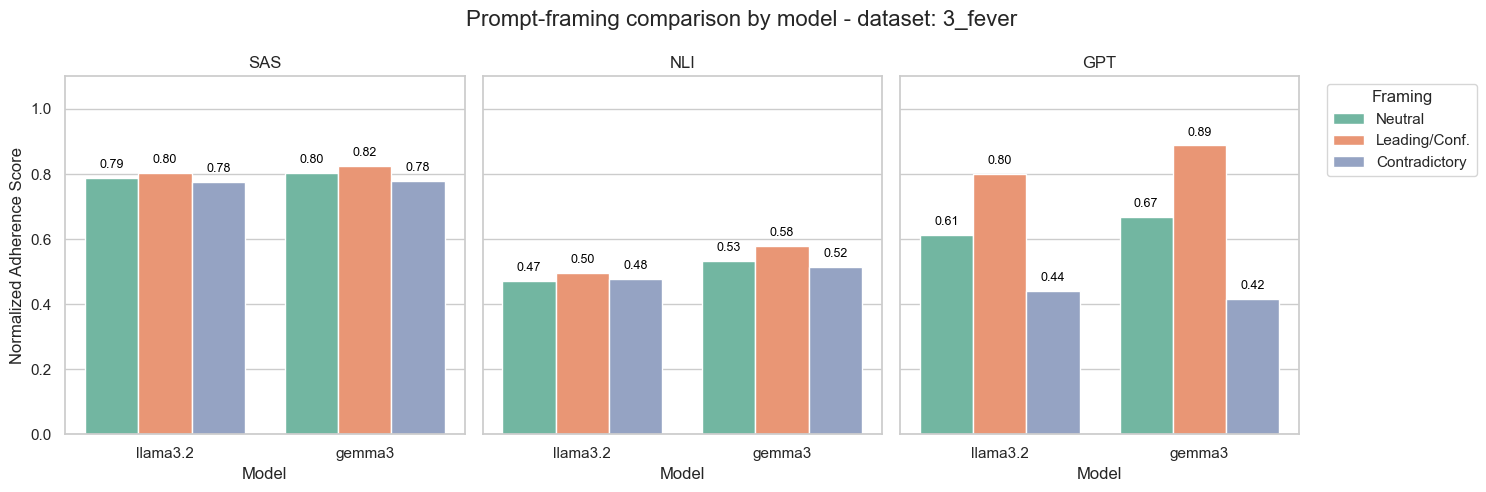

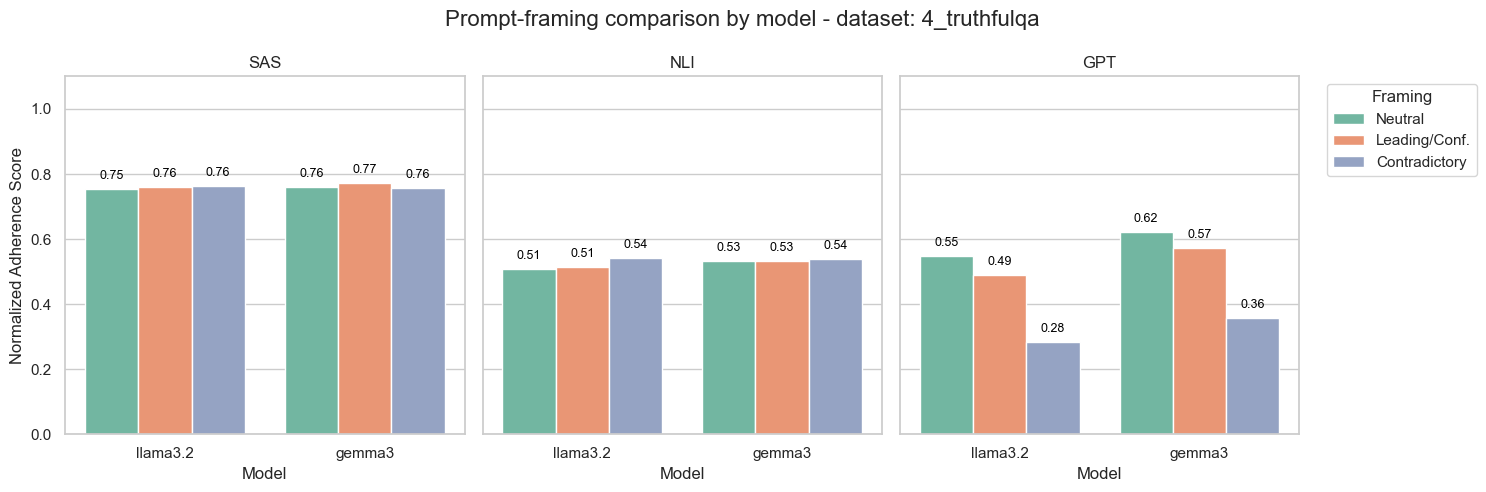

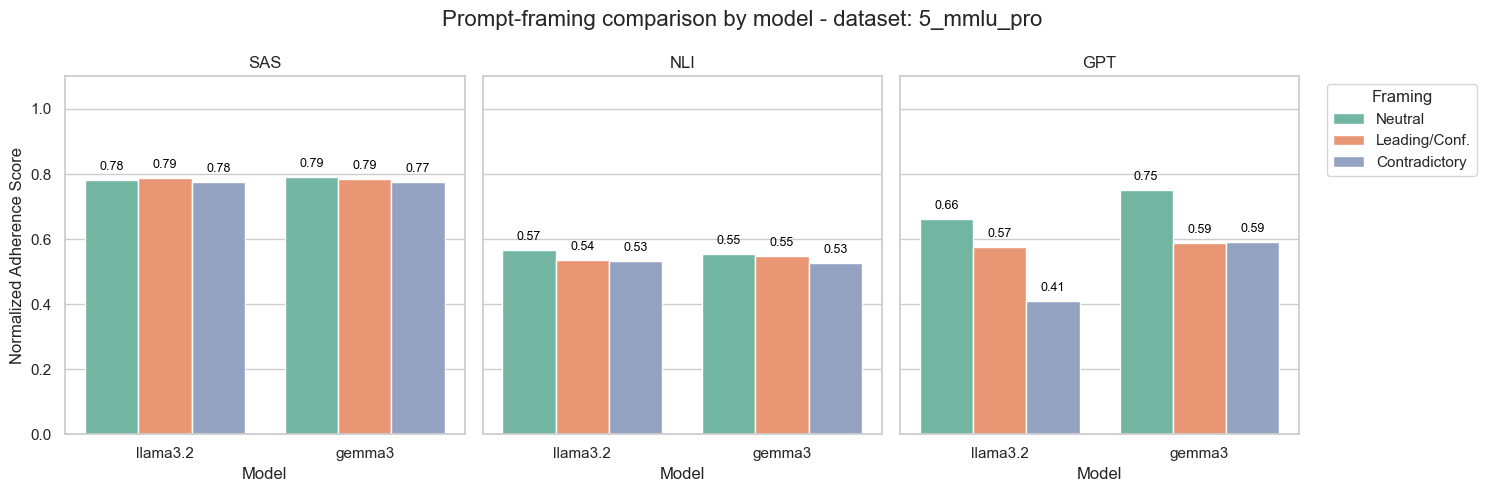

In [29]:
if not df_all.empty:
    for dataset_name in DATASETS_TO_COMPARE:
        df_dataset = df_by_dataset.get(dataset_name)
        if df_dataset is None or df_dataset.empty:
            print(f"[{dataset_name}] No framing data available.")
            continue

        plot_framing_comparison(
            df_dataset,
            x_col="model",
            x_order=MODELS_TO_COMPARE,
            title=f"Prompt-framing comparison by model - dataset: {dataset_name}",
        )
else:
    print("No combined data available for framing plots by dataset.")

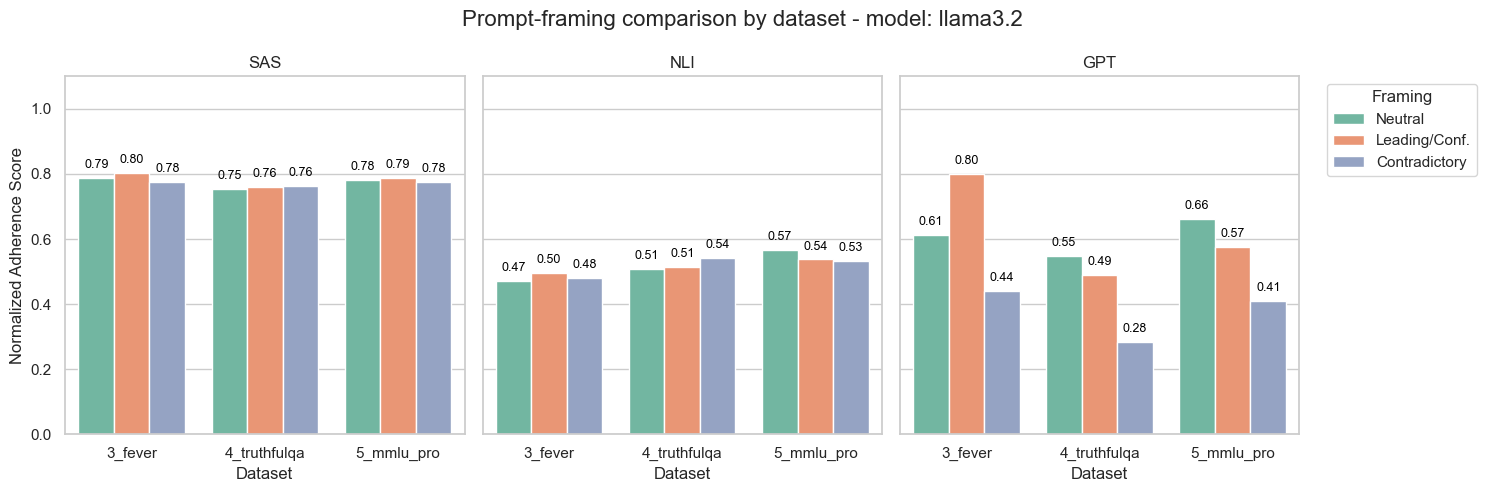

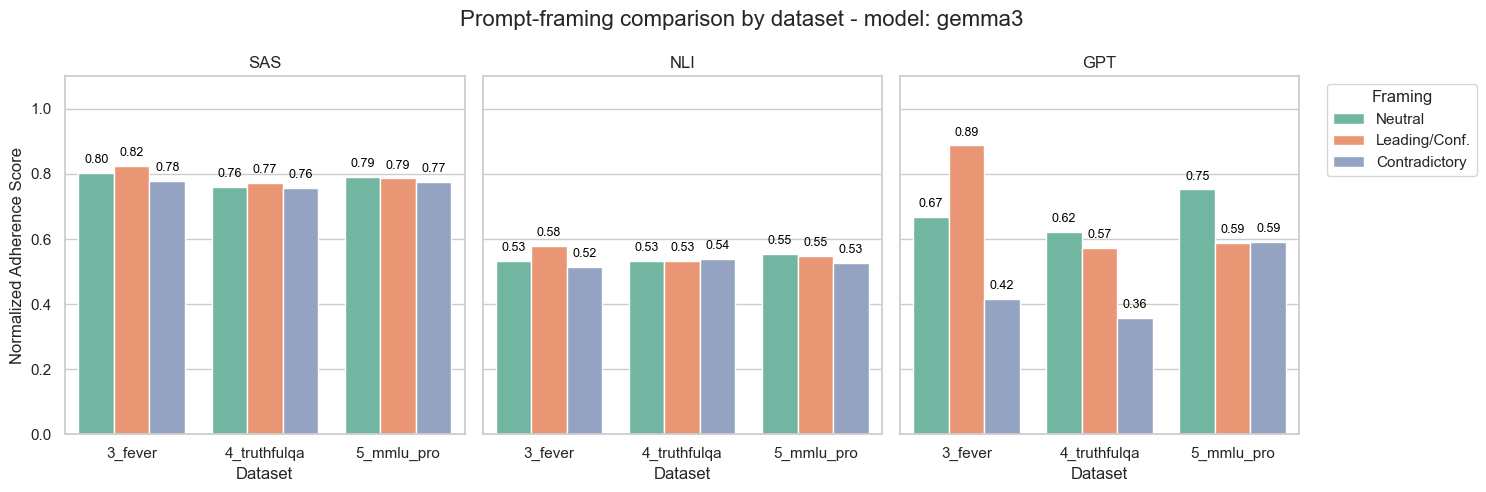

In [30]:
if not df_all.empty:
    for model_name in MODELS_TO_COMPARE:
        df_model = df_by_model.get(model_name)
        if df_model is None or df_model.empty:
            print(f"[{model_name}] No framing data available.")
            continue

        plot_framing_comparison(
            df_model,
            x_col="dataset",
            x_order=DATASETS_TO_COMPARE,
            title=f"Prompt-framing comparison by dataset - model: {model_name}",
        )
else:
    print("No combined data available for framing plots by model.")

## **Comparison of Models and Datasets**
Visualizing the distribution of bias severity and overall scores across datasets and models.

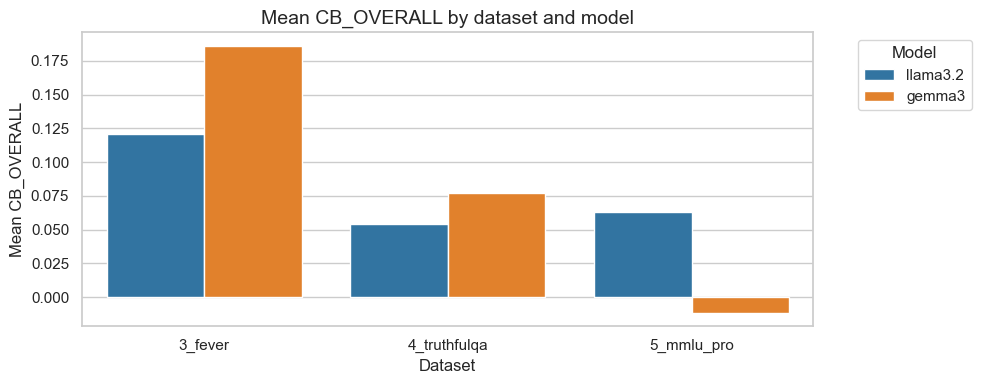

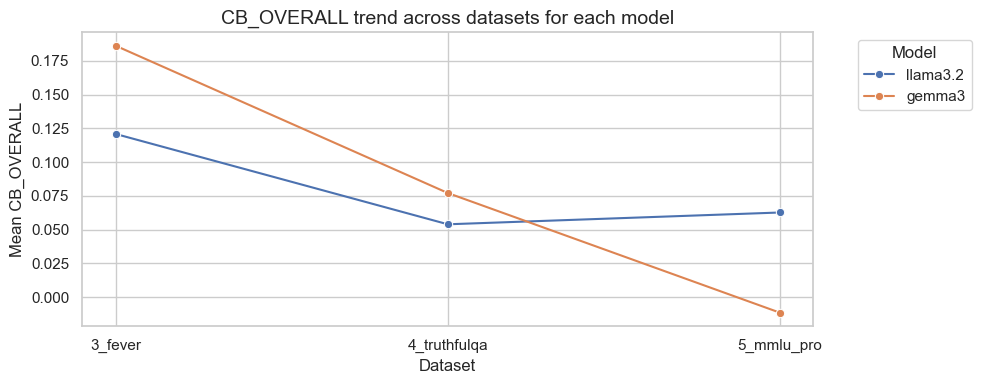

In [31]:
if not df_all.empty:
    summary_cb = (
        df_all.groupby(["dataset", "model"])["CB_OVERALL"]
        .agg(["mean", "std"])
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(data=summary_cb, x="dataset", y="mean", hue="model", hue_order=MODELS_TO_COMPARE, palette="tab10")
    plt.title("Mean CB_OVERALL by dataset and model", fontsize=14)
    plt.ylabel("Mean CB_OVERALL")
    plt.xlabel("Dataset")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=summary_cb, x="dataset", y="mean", hue="model", hue_order=MODELS_TO_COMPARE, marker="o")
    plt.title("CB_OVERALL trend across datasets for each model", fontsize=14)
    plt.ylabel("Mean CB_OVERALL")
    plt.xlabel("Dataset")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No combined data available for cross-dataset / cross-model trend plots.")

In [32]:
if not df_all.empty:
    os.makedirs(BASE_DATA_DIR, exist_ok=True)

    for dataset_name, df_dataset in df_by_dataset.items():
        output_dataset_file = os.path.join(BASE_DATA_DIR, f"{dataset_name}_cb_overall_analysis.csv")
        df_dataset.to_csv(output_dataset_file, index=False)
        print(f"Saved dataset-level results to {output_dataset_file}")

    combined_output_file = os.path.join(BASE_DATA_DIR, "multi_dataset_cb_overall_analysis.csv")
    df_all.to_csv(combined_output_file, index=False)
    print(f"Saved the combined multi-dataset analysis to {combined_output_file}")
else:
    print("No combined data available to export.")

Saved dataset-level results to ../data/processed/3_fever_cb_overall_analysis.csv
Saved dataset-level results to ../data/processed/4_truthfulqa_cb_overall_analysis.csv
Saved dataset-level results to ../data/processed/5_mmlu_pro_cb_overall_analysis.csv
Saved the combined multi-dataset analysis to ../data/processed/multi_dataset_cb_overall_analysis.csv


## **Exporting**
Export the final results to CSV files separated by dataset and as a combined multi-dataset file.

In [33]:
if not df_all.empty:
    os.makedirs(BASE_DATA_DIR, exist_ok=True)

    for dataset_name, df_dataset in df_by_dataset.items():
        output_dataset_file = os.path.join(BASE_DATA_DIR, f"{dataset_name}_cb_overall_analysis.csv")
        df_dataset.to_csv(output_dataset_file, index=False)
        print(f"Saved dataset-level results to {output_dataset_file}")

    combined_output_file = os.path.join(BASE_DATA_DIR, "multi_dataset_cb_overall_analysis.csv")
    df_all.to_csv(combined_output_file, index=False)
    print(f"Saved the combined multi-dataset analysis to {combined_output_file}")
else:
    print("No combined data available to export.")

Saved dataset-level results to ../data/processed/3_fever_cb_overall_analysis.csv
Saved dataset-level results to ../data/processed/4_truthfulqa_cb_overall_analysis.csv
Saved dataset-level results to ../data/processed/5_mmlu_pro_cb_overall_analysis.csv
Saved the combined multi-dataset analysis to ../data/processed/multi_dataset_cb_overall_analysis.csv
